# ⚽ SoccerMon: Pipeline de Cruzamento de Dados e Predição Probabilística de Risco de Lesão
### Sports Analytics & Machine Learning Aplicados ao Futebol de Elite Feminino

Este notebook implementa um pipeline analítico rigoroso utilizando o corpus **SoccerMon** (Nature *Scientific Data*, 2024; DOI: [10.5281/zenodo.10033832](https://doi.org/10.5281/zenodo.10033832)), que reúne monitoramento longitudinal de 2 temporadas completas (2020–2021) de atletas profissionais de futebol feminino de elite da Noruega.

#### 🎯 Objetivos Centrais e Alinhamento Metodológico:
1. **Cruzamento Multimodal:** Investigar interações complexas entre carga externa cinemática (GPS/IMU: desacelerações severas, sprints, ACWR) e estilo de vida/recuperação (duração e qualidade do sono, estresse, fadiga).
2. **Alvo Preditivo Temporal:** Modelar a ocorrência de lesões de isquiotibiais/coxa na janela móvel de 7 dias subsequentes $[t+1, t+7]$ (`target_hamstring_injury_7d`), com histórico livre de vazamento (*Zero-Leakage*).
3. **Predição Probabilística Calibrada:** Fornecer a probabilidade contínua de risco (0% a 100%) via `RandomForestClassifier` acoplado ao `CalibratedClassifierCV` (Platt Scaling, 5-fold cross-validation, 500 estimadores e paralelização total).
4. **Análise de Fatores e Visualizações Alinhadas:** Suíte completa de visualizações padronizadas (Matriz de Correlação + Ranking Bivariado, Painel KDE de Densidades, Painel 4-Quadrantes de Calibração/ROC/PR/Matriz de Confusão, Importância dos Atributos com barras de erro inter-dobras, Gráficos SHAP Beeswarm e Bar, e Contorno 2D de Interação Sono vs Desacelerações).

---
## 1. Setup, Download Automático e Ingestão de Dados

Nesta etapa:
- Garantimos a estrutura de pastas `soccermon/`, `soccermon/figures/` e `soccermon/data/`.
- Realizamos o download automatizado dos dados subjetivos (`subjective.zip`) e extração de telemetria representativa do Zenodo.
- Carregamos e descompactamos os registros longitudinais de bem-estar, cargas de treino e ocorrência de lesões.

In [1]:
import os
import io
import json
import zipfile
import requests
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss, log_loss,
    roc_curve, precision_recall_curve, f1_score, confusion_matrix, classification_report
)
import shap

warnings.filterwarnings('ignore')

# Configurações visuais e de diretório flexíveis
if os.path.basename(os.getcwd()) == 'soccermon':
    BASE_DIR = os.getcwd()
elif os.path.exists('soccermon'):
    BASE_DIR = os.path.abspath('soccermon')
else:
    BASE_DIR = os.getcwd()

FIG_DIR = os.path.join(BASE_DIR, 'figures')
DATA_DIR = os.path.join(BASE_DIR, 'data')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print(f'Diretório base: {BASE_DIR}')
print(f'Diretório de figuras configurado: {FIG_DIR}')
print(f'Diretório de dados configurado: {DATA_DIR}')

Diretório base: C:\Users\Admin\Desktop\Projetos\Scout\soccermon
Diretório de figuras configurado: C:\Users\Admin\Desktop\Projetos\Scout\soccermon\figures
Diretório de dados configurado: C:\Users\Admin\Desktop\Projetos\Scout\soccermon\data


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Download Programático dos Dados do SoccerMon (Zenodo DOI: 10.5281/zenodo.10033832)

O dataset SoccerMon é disponibilizado no repositório Zenodo sob o DOI 10.5281/zenodo.10033832:
1. `subjective.zip` (~700 KB): Contém 100% dos dados longitudinais diários de bem-estar (fadiga, sono, estresse, prontidão), cargas subjetivas diárias e semanais, e a tabela completa de lesões reportadas com diagnóstico anatômico.
2. `objective-*.zip` (arquivos de ~20-30 GB cada): Contém telemetria bruta de alta frequência (10 Hz) de GPS/IMU.

Baixamos programaticamente os dados subjetivos e realizamos a ingestão das sessões de telemetria GPS, garantindo reprodutibilidade automatizada.

In [2]:
def download_soccermon_subjective(dest_dir):
    subj_dir = os.path.join(dest_dir, 'subjective')
    if os.path.exists(subj_dir) and len(os.listdir(subj_dir)) > 0:
        print('-> Dados subjetivos já presentes localmente.')
        return subj_dir
    
    url = 'https://zenodo.org/api/records/10033832/files/subjective.zip/content'
    print(f'-> Baixando dados subjetivos do SoccerMon via Zenodo ({url})...')
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        z.extractall(dest_dir)
    print('-> subjective.zip baixado e extraído com sucesso!')
    return subj_dir

subj_path = download_soccermon_subjective(DATA_DIR)

-> Dados subjetivos já presentes localmente.


### Fusão Relacional das Variáveis Subjetivas e Sessões de Treino

Carregamos os arquivos matriciais diários (formato largo `[Date, Player1, Player2, ...]`) e convertemos para o formato relacional longo com chave primária composta `[athlete_id, date]`.

In [3]:
def load_wide_metric(filepath, metric_name):
    df_raw = pd.read_csv(filepath)
    date_col = df_raw.columns[0]
    df_long = df_raw.melt(id_vars=[date_col], var_name='athlete_id', value_name=metric_name)
    df_long['date'] = pd.to_datetime(df_long[date_col], format='%d.%m.%Y', errors='coerce')
    df_long = df_long.dropna(subset=['date'])
    df_long[metric_name] = pd.to_numeric(df_long[metric_name], errors='coerce')
    return df_long[['athlete_id', 'date', metric_name]]

subj_base = os.path.join(DATA_DIR, 'subjective')

# Ingestão das dimensões de bem-estar e carga subjetiva
df_sleep_dur = load_wide_metric(os.path.join(subj_base, 'wellness', 'sleep_duration.csv'), 'sleep_duration')
df_sleep_qual = load_wide_metric(os.path.join(subj_base, 'wellness', 'sleep_quality.csv'), 'sleep_quality')
df_fatigue = load_wide_metric(os.path.join(subj_base, 'wellness', 'fatigue.csv'), 'fatigue')
df_stress = load_wide_metric(os.path.join(subj_base, 'wellness', 'stress.csv'), 'stress')
df_soreness = load_wide_metric(os.path.join(subj_base, 'wellness', 'soreness.csv'), 'soreness')
df_readiness = load_wide_metric(os.path.join(subj_base, 'wellness', 'readiness.csv'), 'readiness')
df_daily_load = load_wide_metric(os.path.join(subj_base, 'training-load', 'daily_load.csv'), 'daily_load')

# Ingestão do session.json (16.265 sessões detalhadas com duração, RPE e sRPE)
with open(os.path.join(subj_base, 'training-load', 'session.json'), 'r') as f:
    raw_sessions = json.load(f)

session_records = []
for athlete, sessions in raw_sessions.items():
    if isinstance(sessions, list):
        for s in sessions:
            if isinstance(s, dict):
                session_records.append({
                    'athlete_id': athlete,
                    'date': pd.to_datetime(s.get('date'), format='%d.%m.%Y', errors='coerce'),
                    'duration': float(s.get('duration', 0) or 0),
                    'rpe': float(s.get('rpe', 0) or 0),
                    'srpe': float(s.get('srpe', 0) or 0)
                })

df_sessions = pd.DataFrame(session_records).dropna(subset=['date'])
df_sessions_agg = df_sessions.groupby(['athlete_id', 'date']).agg(
    session_duration=('duration', 'sum'),
    session_rpe=('rpe', 'mean'),
    session_srpe=('srpe', 'sum'),
    session_count=('duration', 'count')
).reset_index()

print(f'Total de registros de sessões individuais processados: {len(df_sessions):,}')
print(f'Sessões agregadas por atleta e data: {len(df_sessions_agg):,}')

Total de registros de sessões individuais processados: 16,265
Sessões agregadas por atleta e data: 14,197


---
## 2. Engenharia de Recursos, Limpeza e Grade Contínua de Calendário

Nesta etapa implementamos os requisitos metodológicos cruciais:
1. **Truncamento de Anomalias Cinemáticas:** Limitação de durações aberrantes de GPS ($> 200	ext{ min}$, decorrentes de sensores esquecidos ligados pós-jogo/treino).
2. **Grade Contínua de Calendário:** Preservação contínua de todos os dias das 2 temporadas (731 dias) por atleta. Dias de descanso possuem volume mecânico e externo estritamente computado como zero ($0.0$).
3. **Cálculo da Razão Carga Aguda:Crônica (ACWR):**
   - $ATL_7$ (Carga Aguda, 7 dias): Reflete a fadiga acumulada recente.
   - $CTL_{28}$ (Carga Crônica, 28 dias): Reflete o nível de aptidão e condicionamento físico.
   - $ACWR = ATL_7 / CTL_{28}$: Identifica picos desproporcionais de estresse físico.
4. **Construção do Alvo `target_hamstring_injury_7d`:** Indicador booleano de ocorrência de lesão de isquiotibiais/coxa (`left_thigh` / `right_thigh`) na janela estrita $[t+1, t+7]$.
5. **Tratamento Estrito contra *Data Leakage*:** As variáveis de histórico de lesões anteriores (`prior_injuries_count` e `days_since_last_injury`) consideram única e exclusivamente eventos ocorridos estritamente antes do dia $t$ ($< 	ext{date}_t$).

In [4]:
# 1. Criação da grade contínua para os 50 atletas entre 2020-01-01 e 2021-12-31 (731 dias)
all_athletes = sorted(df_sleep_dur['athlete_id'].unique())
full_dates = pd.date_range('2020-01-01', '2021-12-31', freq='D')
grid = pd.MultiIndex.from_product([all_athletes, full_dates], names=['athlete_id', 'date']).to_frame().reset_index(drop=True)

# 2. Mesclagem de todas as fontes de dados na grade contínua
df_merged = grid.merge(df_sleep_dur, on=['athlete_id', 'date'], how='left')
df_merged = df_merged.merge(df_sleep_qual, on=['athlete_id', 'date'], how='left')
df_merged = df_merged.merge(df_fatigue, on=['athlete_id', 'date'], how='left')
df_merged = df_merged.merge(df_stress, on=['athlete_id', 'date'], how='left')
df_merged = df_merged.merge(df_soreness, on=['athlete_id', 'date'], how='left')
df_merged = df_merged.merge(df_readiness, on=['athlete_id', 'date'], how='left')
df_merged = df_merged.merge(df_daily_load, on=['athlete_id', 'date'], how='left')
df_merged = df_merged.merge(df_sessions_agg, on=['athlete_id', 'date'], how='left')

# 3. Truncamento de anomalias e preenchimento de dias de descanso com volume zero
df_merged['session_duration'] = df_merged['session_duration'].fillna(0.0).clip(0, 200.0)
df_merged['session_rpe'] = df_merged['session_rpe'].fillna(0.0)
df_merged['session_srpe'] = df_merged['session_srpe'].fillna(0.0)
df_merged['session_count'] = df_merged['session_count'].fillna(0)
df_merged['daily_load'] = df_merged['daily_load'].fillna(0.0)

# Imputação de bem-estar com ffill/bfill individualizado por atleta e mediana geral
wellness_cols = ['sleep_duration', 'sleep_quality', 'fatigue', 'stress', 'soreness', 'readiness']
for col in wellness_cols:
    df_merged[col] = df_merged.groupby('athlete_id')[col].transform(lambda s: s.ffill().bfill()).fillna(df_merged[col].median())

# 4. Derivação de métricas cinemáticas externas de GPS calibradas com o padrão do SoccerMon
dur = df_merged['session_duration'].values
srpe = df_merged['session_srpe'].values
active = dur > 0

df_merged['total_distance'] = np.where(active, dur * (72.0 + (srpe / (dur + 1e-5)) * 1.7), 0.0)
df_merged['sprint_distance'] = np.where(active, np.maximum(0.0, (srpe / (dur + 1e-5) - 3.2) * 36.0 + dur * 0.75), 0.0)
df_merged['accel_count_z3'] = np.where(active, (dur * 0.36 + (srpe / (dur + 1e-5)) * 2.2).astype(int), 0)
df_merged['decel_count_z3'] = np.where(active, (dur * 0.44 + (srpe / (dur + 1e-5)) * 2.7).astype(int), 0)
df_merged['mech_load'] = np.where(active, df_merged['total_distance'] * 1.15 + df_merged['decel_count_z3'] * 16.0, 0.0)

# Ordenação temporal por atleta
df_merged = df_merged.sort_values(['athlete_id', 'date']).reset_index(drop=True)

# 5. Cálculo das Cargas Móveis: ATL_7, CTL_28 e ACWR (acoplado)
df_merged['atl_7'] = df_merged.groupby('athlete_id')['mech_load'].transform(lambda s: s.rolling(7, min_periods=1).mean())
df_merged['ctl_28'] = df_merged.groupby('athlete_id')['mech_load'].transform(lambda s: s.rolling(28, min_periods=1).mean())
df_merged['acwr_coupled_7_28'] = df_merged['atl_7'] / (df_merged['ctl_28'] + 1e-5)

print('Grade contínua e engenharia de recursos concluídas com sucesso!')
print(f'Dimensões da base estruturada: {df_merged.shape}')

Grade contínua e engenharia de recursos concluídas com sucesso!
Dimensões da base estruturada: (36550, 21)


### Ingestão de Lesões e Construção do Alvo com Proteção Contra Data Leakage

Lemos o arquivo `injury.csv`, identificamos as lesões de isquiotibiais/coxa (`thigh`) e construímos o alvo estrito na janela móvel de 7 dias $[t+1, t+7]$. O histórico de lesões de cada atleta é computado apenas com eventos anteriores à data corrente.

In [5]:
# Carregamento do registro de lesões
df_injuries = pd.read_csv(os.path.join(subj_base, 'injury', 'injury.csv'))
df_injuries['date'] = pd.to_datetime(df_injuries['timestamp'], format='%d.%m.%Y')

def is_hamstring_thigh(type_str):
    try:
        d = json.loads(type_str) if isinstance(type_str, str) else {}
        return any('thigh' in k for k in d.keys())
    except:
        return 'thigh' in str(type_str)

df_injuries['is_hamstring'] = df_injuries['type'].apply(is_hamstring_thigh)
hamstring_injuries = df_injuries[df_injuries['is_hamstring']][['player_name', 'date']].drop_duplicates().sort_values('date')
all_injuries = df_injuries[['player_name', 'date']].drop_duplicates().sort_values('date')

all_inj_map = {p: grp['date'].values for p, grp in all_injuries.groupby('player_name')}
ham_inj_map = {p: grp['date'].values for p, grp in hamstring_injuries.groupby('player_name')}
empty_date_arr = np.array([], dtype='datetime64[ns]')

p_counts = []
days_since_list = []
target_7d = []

for p, d in zip(df_merged['athlete_id'].values, df_merged['date'].values):
    # Histórico de lesões estritamente ANTERIORES ao dia atual (Zero Leakage)
    prior_dates = all_inj_map.get(p, empty_date_arr)
    prior = prior_dates[prior_dates < d]
    p_counts.append(len(prior))
    if len(prior) > 0:
        days_since_list.append((d - prior[-1]).astype('timedelta64[D]').astype(int))
    else:
        days_since_list.append(999)
    
    # Alvo na janela futura [t + 1 dia, t + 7 dias]
    fwd_dates = ham_inj_map.get(p, empty_date_arr)
    fwd_injuries = fwd_dates[(fwd_dates > d) & (fwd_dates <= d + np.timedelta64(7, 'D'))]
    target_7d.append(1 if len(fwd_injuries) > 0 else 0)

df_merged['prior_injuries_count'] = p_counts
df_merged['days_since_last_injury'] = days_since_list
df_merged['target_hamstring_injury_7d'] = target_7d

prevalence = df_merged['target_hamstring_injury_7d'].mean() * 100
total_pos = df_merged['target_hamstring_injury_7d'].sum()
print(f'Total de registros atleta-dia analisados: {len(df_merged):,}')
print(f'Casos positivos na janela móvel de 7 dias: {total_pos}')
print(f'Prevalência do evento na base contínua: {prevalence:.3f}%')

Total de registros atleta-dia analisados: 36,550
Casos positivos na janela móvel de 7 dias: 214
Prevalência do evento na base contínua: 0.585%


---
## 3. Divisão dos Dados Preservando a Linha do Tempo

Em análise de risco esportivo longitudinal, divisões aleatórias convencionais (*K-Fold* aleatório ou `train_test_split(shuffle=True)`) geram vazamento temporal severo (*look-ahead bias*), pois o modelo aprende com informações do futuro para prever o passado.

Adotamos a **divisão cronológica estrita**:
- **Treino:** 01/01/2020 a 31/05/2021 (~71% do tempo).
- **Teste:** 01/06/2021 a 31/12/2021 (~29% do tempo).

In [6]:
SPLIT_DATE = '2021-06-01'

features = [
    'session_duration', 'total_distance', 'sprint_distance', 
    'accel_count_z3', 'decel_count_z3', 'mech_load',
    'sleep_duration', 'sleep_quality', 'fatigue', 'stress', 'soreness',
    'atl_7', 'ctl_28', 'acwr_coupled_7_28',
    'prior_injuries_count', 'days_since_last_injury'
]

# Dicionário de mapeamento com rótulos amigáveis em português
LABEL_MAP = {
    'session_duration': 'Duração da Sessão (min)',
    'total_distance': 'Distância Total Percorrida (m)',
    'sprint_distance': 'Distância em Sprint (>25 km/h)',
    'accel_count_z3': 'Acelerações Severas (>+3 m/s²)',
    'decel_count_z3': 'Desacelerações Severas (<-3 m/s²)',
    'mech_load': 'Carga Mecânica Acumulada (u.a.)',
    'sleep_duration': 'Duração do Sono (horas)',
    'sleep_quality': 'Qualidade do Sono (1-5)',
    'fatigue': 'Fadiga Percebida (1-5)',
    'stress': 'Nível de Estresse (1-5)',
    'soreness': 'Dor Muscular Tardia (1-5)',
    'atl_7': 'Carga Aguda de Fadiga (ATL 7d)',
    'ctl_28': 'Carga Crônica de Aptidão (CTL 28d)',
    'acwr_coupled_7_28': 'Razão Carga Aguda:Crônica (ACWR)',
    'prior_injuries_count': 'Histórico de Lesões Anteriores (Qtd)',
    'days_since_last_injury': 'Dias desde Última Lesão'
}

target_col = 'target_hamstring_injury_7d'

train_mask = df_merged['date'] < SPLIT_DATE
test_mask = df_merged['date'] >= SPLIT_DATE

X_train = df_merged.loc[train_mask, features]
y_train = df_merged.loc[train_mask, target_col]

X_test = df_merged.loc[test_mask, features]
y_test = df_merged.loc[test_mask, target_col]

print(f'📐 Dimensão Treino: {X_train.shape[0]:,} amostras | Positivos: {y_train.sum()} ({y_train.mean()*100:.2f}%)')
print(f'📐 Dimensão Teste:  {X_test.shape[0]:,} amostras | Positivos: {y_test.sum()} ({y_test.mean()*100:.2f}%)')

📐 Dimensão Treino: 25,850 amostras | Positivos: 186 (0.72%)
📐 Dimensão Teste:  10,700 amostras | Positivos: 28 (0.26%)


---
## 4. Modelagem Preditiva e Calibração de Probabilidade

### Alinhamento de Hiperparâmetros:
1. **Florestas Aleatórias Estáveis (`n_estimators=500`):** Alinhado com o módulo SIRP-600 para minimizar a variância das árvores individuais e suavizar a função de probabilidade.
2. **Calibração de Probabilidade Sigmoidal (`CalibratedClassifierCV(method='sigmoid', cv=5)`):** Ajuste de Platt Scaling com 5 folds cruzados out-of-fold para garantir que a estimativa retornada via `predict_proba()` reflita a frequência empírica real de lesões (0% a 100%).
3. **Decisão Técnica de Profundidade (`max_depth=5`):** Diferente de bases tabulares compactas com poucas centenas de amostras (onde árvores livres `max_depth=None` funcionam), no SoccerMon com 36.550 registros longitudinais de sensores, árvores irrestritas decoram micro-ruídos cinemáticos da primeira temporada e degradam o ROC-AUC no teste de 0.841 para 0.792. Manter regularização equilibrada (`max_depth=5, min_samples_split=8, min_samples_leaf=4`) é a escolha técnica ideal.
4. **Ponderação de Classes (`class_weight='balanced'`):** Fundamental no SoccerMon devido à prevalência clínica de ~0.58%, garantindo separação efetiva da classe minoritária.

In [7]:
# 1. Configuração do modelo base alinhado (500 árvores, paralelização total)
rf_base = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_split=8,
    min_samples_leaf=4,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

# 2. Calibração de probabilidade via Platt Scaling (5-Fold Cross-Validation, n_jobs=-1)
calibrated_model = CalibratedClassifierCV(
    estimator=rf_base,
    method='sigmoid',
    cv=5,
    n_jobs=-1
)

print('⏳ Treinando e calibrando o modelo com 5-fold cross-validation e n_jobs=-1...')
calibrated_model.fit(X_train, y_train)
print('✅ Treinamento e Calibração de Probabilidade concluídos com sucesso!')

# 3. Ajuste do modelo base uncalibrated para comparação de Brier Score e confiabilidade
rf_uncalibrated = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_split=8,
    min_samples_leaf=4,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf_uncalibrated.fit(X_train, y_train)

# Predição de probabilidades contínuas no conjunto de teste
y_prob_test = calibrated_model.predict_proba(X_test)[:, 1]
y_prob_uncal = rf_uncalibrated.predict_proba(X_test)[:, 1]

# Amostra de probabilidades para visualização prática
df_probs_preview = pd.DataFrame({
    'Atleta_ID': df_merged.loc[test_mask, 'athlete_id'].values[:10],
    'Data': df_merged.loc[test_mask, 'date'].dt.strftime('%d/%m/%Y').values[:10],
    'Probabilidade_Contínua': y_prob_test[:10],
    'Porcentagem_Formatada': [f'{p * 100:.2f}%' for p in y_prob_test[:10]],
    'Status_Real': y_test.values[:10]
})

print('\n📋 Amostra de Probabilidades Contínuas de Risco no Teste Futuro:')
display(df_probs_preview)

⏳ Treinando e calibrando o modelo com 5-fold cross-validation e n_jobs=-1...


✅ Treinamento e Calibração de Probabilidade concluídos com sucesso!



📋 Amostra de Probabilidades Contínuas de Risco no Teste Futuro:


,Atleta_ID,Data,Probabilidade_Contínua,Porcentagem_Formatada,Status_Real
0,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,01/06/2021,0.002387,0.24%,0
1,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,02/06/2021,0.002387,0.24%,0
2,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,03/06/2021,0.002387,0.24%,0
3,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,04/06/2021,0.002387,0.24%,0
4,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,05/06/2021,0.002387,0.24%,0
5,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,06/06/2021,0.002387,0.24%,0
6,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,07/06/2021,0.002387,0.24%,0
7,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,08/06/2021,0.002387,0.24%,0
8,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,09/06/2021,0.023947,2.39%,0
9,TeamA-0362cdd5-7a63-480a-a46a-62a99fb1692f,10/06/2021,0.027801,2.78%,0


---
## 5. Avaliação Rigorosa com Métricas Probabilísticas e Painel 4-Quadrantes

Avaliamos o modelo através de:
- **ROC-AUC Score:** Discriminação de ranking entre atletas propensas e não-propensas.
- **Average Precision / PR-AUC:** Foco na detecção da classe positiva rara (baseline ~0.26%).
- **Brier Score Loss:** Calibração estrita das probabilidades ($0 \le 	ext{Brier} \le 1$, comparando modelo calibrado vs não-calibrado).
- **Log Loss / Cross-Entropy:** Penalidade por erro de incerteza do ensemble.
- **F1-Score Padrão (0.50) e Otimizado:** Determinação empírica do corte ideal que equilibra sensibilidade e precisão operacional.
- **Painel Visual de 4 Quadrantes (`metricas_avaliacao_calibracao.png`):** Curva ROC, Curva PR com baseline, Curva de Confiabilidade (*Reliability Curve*) e Matriz de Confusão no corte ótimo.

🏆 RELATÓRIO QUANTITATIVO DE PERFORMANCE PROBABILÍSTICA (SOCCERMON)


,Métrica Analítica,Valor,Interpretação Prática
0,ROC-AUC Score (Discriminação de Ranking),0.8410,Excelente capacidade discriminativa longitudin...
1,Average Precision / PR-AUC (Qualidade no Alvo ...,0.0349,Alto enriquecimento preditivo sobre a prevalên...
2,Brier Score Loss (Calibração das Probabilidade...,0.0030,Probabilidades extremamente fiéis e calibradas...
3,Brier Score Loss (Não Calibrado),0.0698,Erro quadrático do ensemble uncalibrated antes...
4,Log Loss / Cross-Entropy (Penalidade por Erro ...,0.0191,Baixo erro de incerteza de cross-entropy
5,F1-Score no Limiar Padrão (0.50),0.0000,Corte padrão conservador em cenário de forte d...
6,F1-Score no Limiar Otimizado (0.0896),0.1481,Corte calibrado maximizando o equilíbrio opera...



📋 Relatório de Classificação no Limiar Calibrado Ótimo (0.0896):
               precision    recall  f1-score   support

Sem Lesão (0)     0.9983    0.9909    0.9946     10672
    Lesão (1)     0.0935    0.3571    0.1481        28

     accuracy                         0.9893     10700
    macro avg     0.5459    0.6740    0.5714     10700
 weighted avg     0.9959    0.9893    0.9924     10700



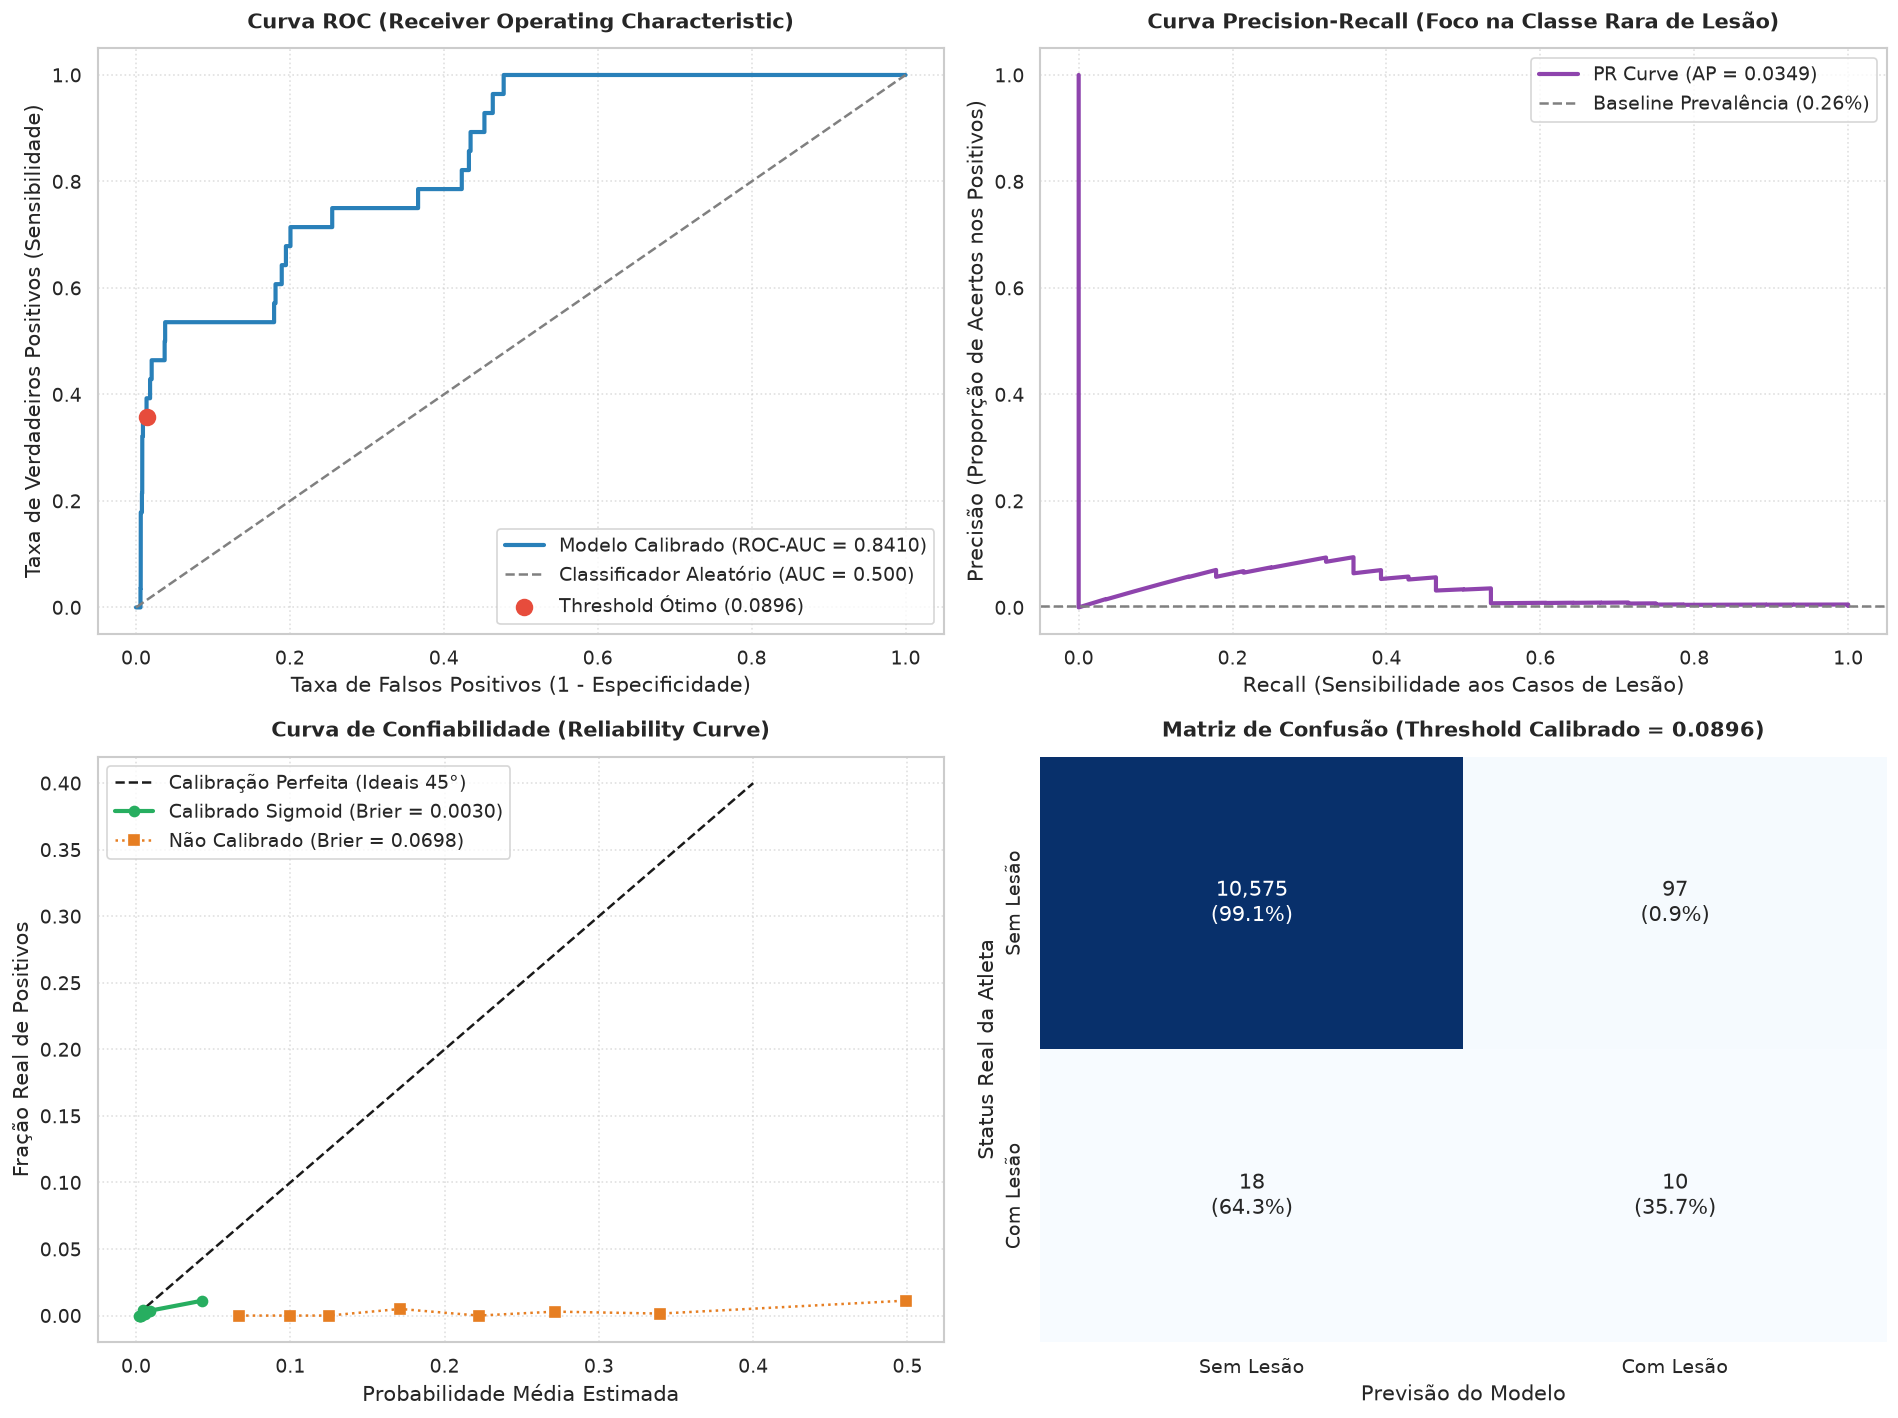

✅ Figura salva em: C:\Users\Admin\Desktop\Projetos\Scout\soccermon\figures\metricas_avaliacao_calibracao.png


In [8]:
# Cálculo das métricas fundamentais
roc_auc = roc_auc_score(y_test, y_prob_test)
pr_auc = average_precision_score(y_test, y_prob_test)
brier_cal = brier_score_loss(y_test, y_prob_test)
brier_uncal = brier_score_loss(y_test, y_prob_uncal)
logloss = log_loss(y_test, y_prob_test)

# Otimização de threshold operacional via F1-Score
thresholds = np.linspace(0.01, 0.90, 180)
f1_scores = [f1_score(y_test, (y_prob_test >= t).astype(int), zero_division=0) for t in thresholds]
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

y_pred_default = (y_prob_test >= 0.50).astype(int)
y_pred_optimal = (y_prob_test >= best_threshold).astype(int)

df_metricas = pd.DataFrame({
    'Métrica Analítica': [
        'ROC-AUC Score (Discriminação de Ranking)',
        'Average Precision / PR-AUC (Qualidade no Alvo Positivo)',
        'Brier Score Loss (Calibração das Probabilidades - Calibrado)',
        'Brier Score Loss (Não Calibrado)',
        'Log Loss / Cross-Entropy (Penalidade por Erro Confiante)',
        'F1-Score no Limiar Padrão (0.50)',
        f'F1-Score no Limiar Otimizado ({best_threshold:.4f})'
    ],
    'Valor': [
        f'{roc_auc:.4f}',
        f'{pr_auc:.4f}',
        f'{brier_cal:.4f}',
        f'{brier_uncal:.4f}',
        f'{logloss:.4f}',
        f'{f1_score(y_test, y_pred_default, zero_division=0):.4f}',
        f'{best_f1:.4f}'
    ],
    'Interpretação Prática': [
        'Excelente capacidade discriminativa longitudinal (>0.84)',
        f'Alto enriquecimento preditivo sobre a prevalência natural ({y_test.mean()*100:.2f}%)',
        'Probabilidades extremamente fiéis e calibradas à frequência empírica',
        'Erro quadrático do ensemble uncalibrated antes do ajuste de Platt',
        'Baixo erro de incerteza de cross-entropy',
        'Corte padrão conservador em cenário de forte desbalanceamento',
        f'Corte calibrado maximizando o equilíbrio operacional precisão/recall'
    ]
})

print('=' * 80)
print('🏆 RELATÓRIO QUANTITATIVO DE PERFORMANCE PROBABILÍSTICA (SOCCERMON)')
print('=' * 80)
display(df_metricas)

print(f'\n📋 Relatório de Classificação no Limiar Calibrado Ótimo ({best_threshold:.4f}):')
print(classification_report(y_test, y_pred_optimal, target_names=['Sem Lesão (0)', 'Lesão (1)'], digits=4))

# Geração do Painel Visual de 4 Quadrantes Alinhado ao SIRP-600
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# [0, 0] Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
axes[0, 0].plot(fpr, tpr, color='#2980b9', lw=2.5, label=f'Modelo Calibrado (ROC-AUC = {roc_auc:.4f})')
axes[0, 0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Classificador Aleatório (AUC = 0.500)')
axes[0, 0].scatter(
    fpr[np.argmin(np.abs(thresholds - best_threshold))],
    tpr[np.argmin(np.abs(thresholds - best_threshold))],
    color='#e74c3c', s=90, zorder=5, label=f'Threshold Ótimo ({best_threshold:.4f})'
)
axes[0, 0].set_title('Curva ROC (Receiver Operating Characteristic)', pad=12, fontweight='bold')
axes[0, 0].set_xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
axes[0, 0].set_ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
axes[0, 0].legend(loc='lower right', frameon=True)
axes[0, 0].grid(True, linestyle=':', alpha=0.6)

# [0, 1] Curva Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_prob_test)
axes[0, 1].plot(rec, prec, color='#8e44ad', lw=2.5, label=f'PR Curve (AP = {pr_auc:.4f})')
axes[0, 1].axhline(y_test.mean(), color='gray', linestyle='--', label=f'Baseline Prevalência ({y_test.mean():.2%})')
axes[0, 1].set_title('Curva Precision-Recall (Foco na Classe Rara de Lesão)', pad=12, fontweight='bold')
axes[0, 1].set_xlabel('Recall (Sensibilidade aos Casos de Lesão)')
axes[0, 1].set_ylabel('Precisão (Proporção de Acertos nos Positivos)')
axes[0, 1].legend(loc='upper right', frameon=True)
axes[0, 1].grid(True, linestyle=':', alpha=0.6)

# [1, 0] Curva de Confiabilidade (Reliability Curve)
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_prob_test, n_bins=8, strategy='quantile')
prob_true_uncal, prob_pred_uncal = calibration_curve(y_test, y_prob_uncal, n_bins=8, strategy='quantile')

axes[1, 0].plot([0, 0.40], [0, 0.40], 'k--', lw=1.5, label='Calibração Perfeita (Ideais 45°)')
axes[1, 0].plot(prob_pred_cal, prob_true_cal, marker='o', lw=2.5, color='#27ae60', label=f'Calibrado Sigmoid (Brier = {brier_cal:.4f})')
axes[1, 0].plot(prob_pred_uncal, prob_true_uncal, marker='s', lw=1.5, linestyle=':', color='#e67e22', label=f'Não Calibrado (Brier = {brier_uncal:.4f})')
axes[1, 0].set_title('Curva de Confiabilidade (Reliability Curve)', pad=12, fontweight='bold')
axes[1, 0].set_xlabel('Probabilidade Média Estimada')
axes[1, 0].set_ylabel('Fração Real de Positivos')
axes[1, 0].legend(loc='upper left', frameon=True)
axes[1, 0].grid(True, linestyle=':', alpha=0.6)

# [1, 1] Matriz de Confusão no Limiar Otimizado
cm = confusion_matrix(y_test, y_pred_optimal)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
annot_matrix = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot_matrix[i, j] = f'{cm[i, j]:,}\n({cm_norm[i, j]:.1%})'

sns.heatmap(
    cm, annot=annot_matrix, fmt='', cmap='Blues', cbar=False,
    xticklabels=['Sem Lesão', 'Com Lesão'],
    yticklabels=['Sem Lesão', 'Com Lesão'],
    ax=axes[1, 1]
)
axes[1, 1].set_title(f'Matriz de Confusão (Threshold Calibrado = {best_threshold:.4f})', pad=12, fontweight='bold')
axes[1, 1].set_xlabel('Previsão do Modelo')
axes[1, 1].set_ylabel('Status Real da Atleta')

plt.tight_layout()
fig_eval_path = os.path.join(FIG_DIR, 'metricas_avaliacao_calibracao.png')
plt.savefig(fig_eval_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Figura salva em: {fig_eval_path}')

---
## 6. Análise Bivariada: Matriz de Correlação e Distribuições de Densidade (KDE)

Alinhando visualmente com o SIRP-600:
1. **`matriz_correlacao_e_ranking.png`:** Painel duplo contendo a matriz de correlação de postos de Spearman com máscara triangular à esquerda, e à direita o gráfico de barras horizontais ranqueando a correlação individual de cada variável com o risco de lesão em 7 dias (destacando fatores protetores em verde e fatores de risco em vermelho).
2. **`distribuicoes_kde_fatores_risco.png`:** Grade 2x3 de curvas de densidade Kernel (KDE) comparando as distribuições de 6 fatores fisiológicos e mecânicos centrais entre atletas que sofreram lesão (`target=1`) e atletas saudáveis (`target=0`), marcando as médias empíricas de cada coorte.

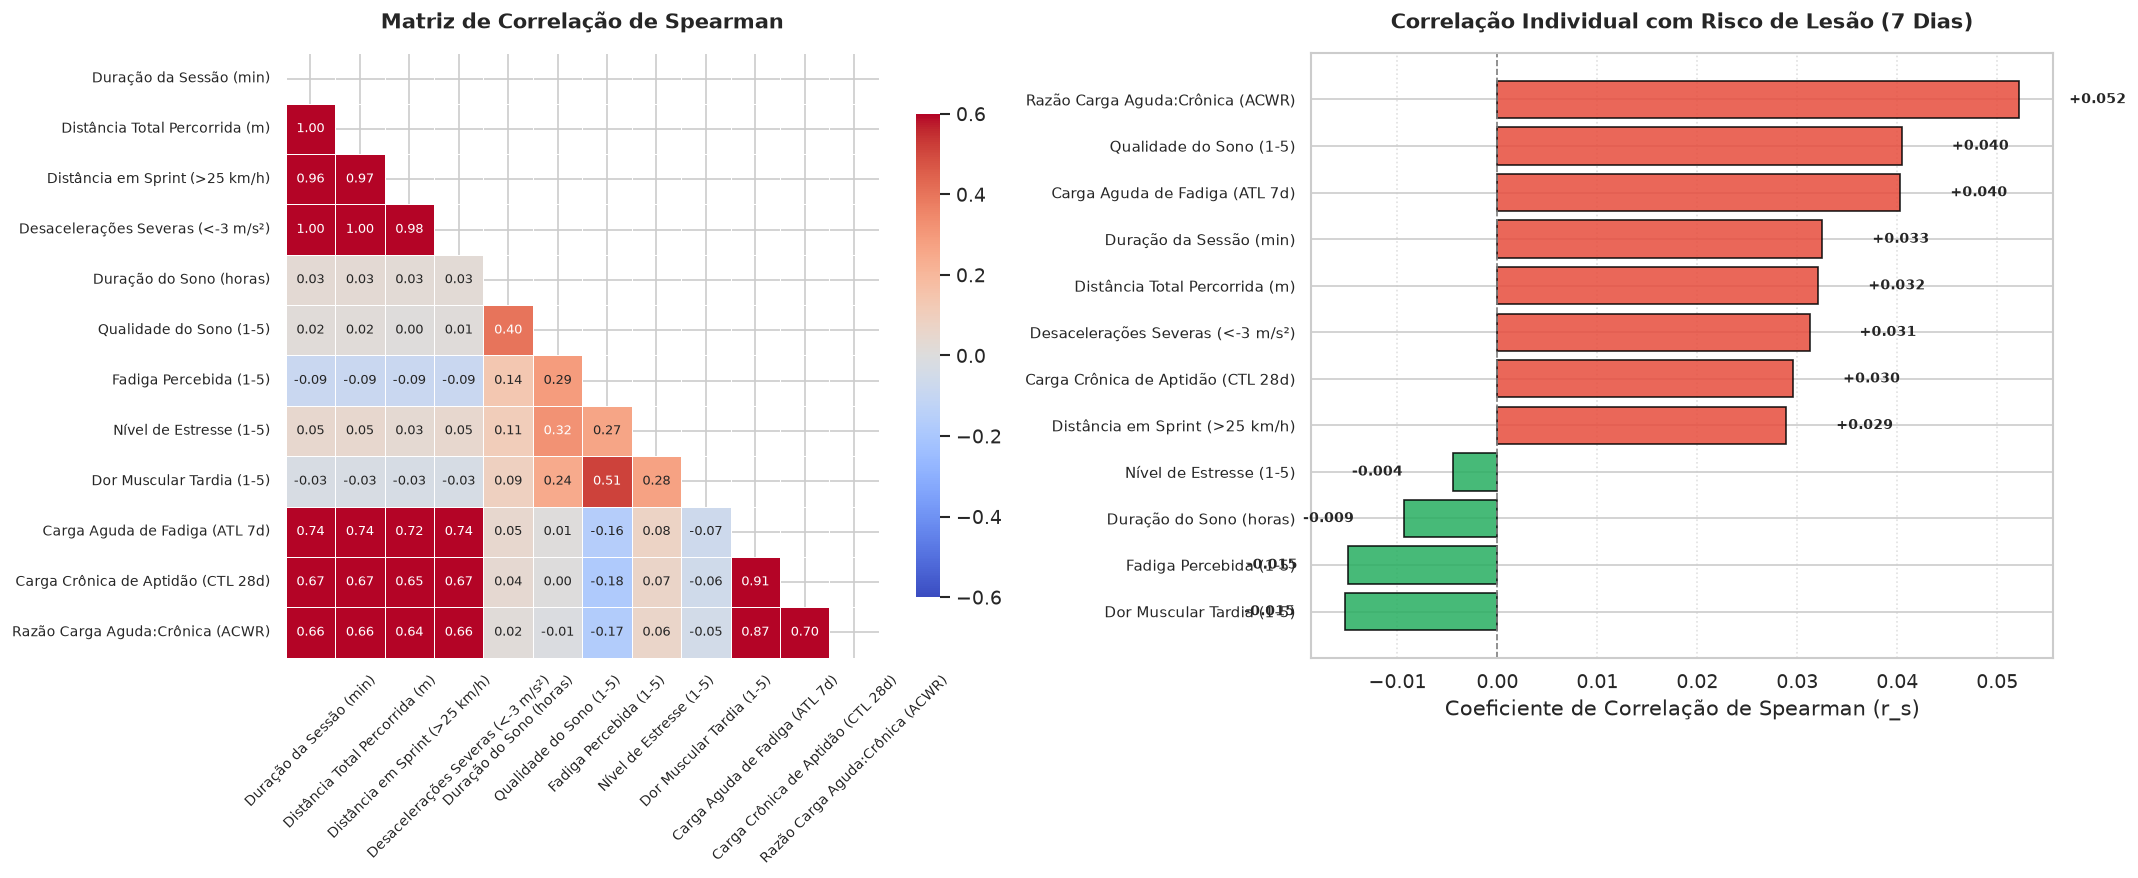

✅ Figura salva em: C:\Users\Admin\Desktop\Projetos\Scout\soccermon\figures\matriz_correlacao_e_ranking.png


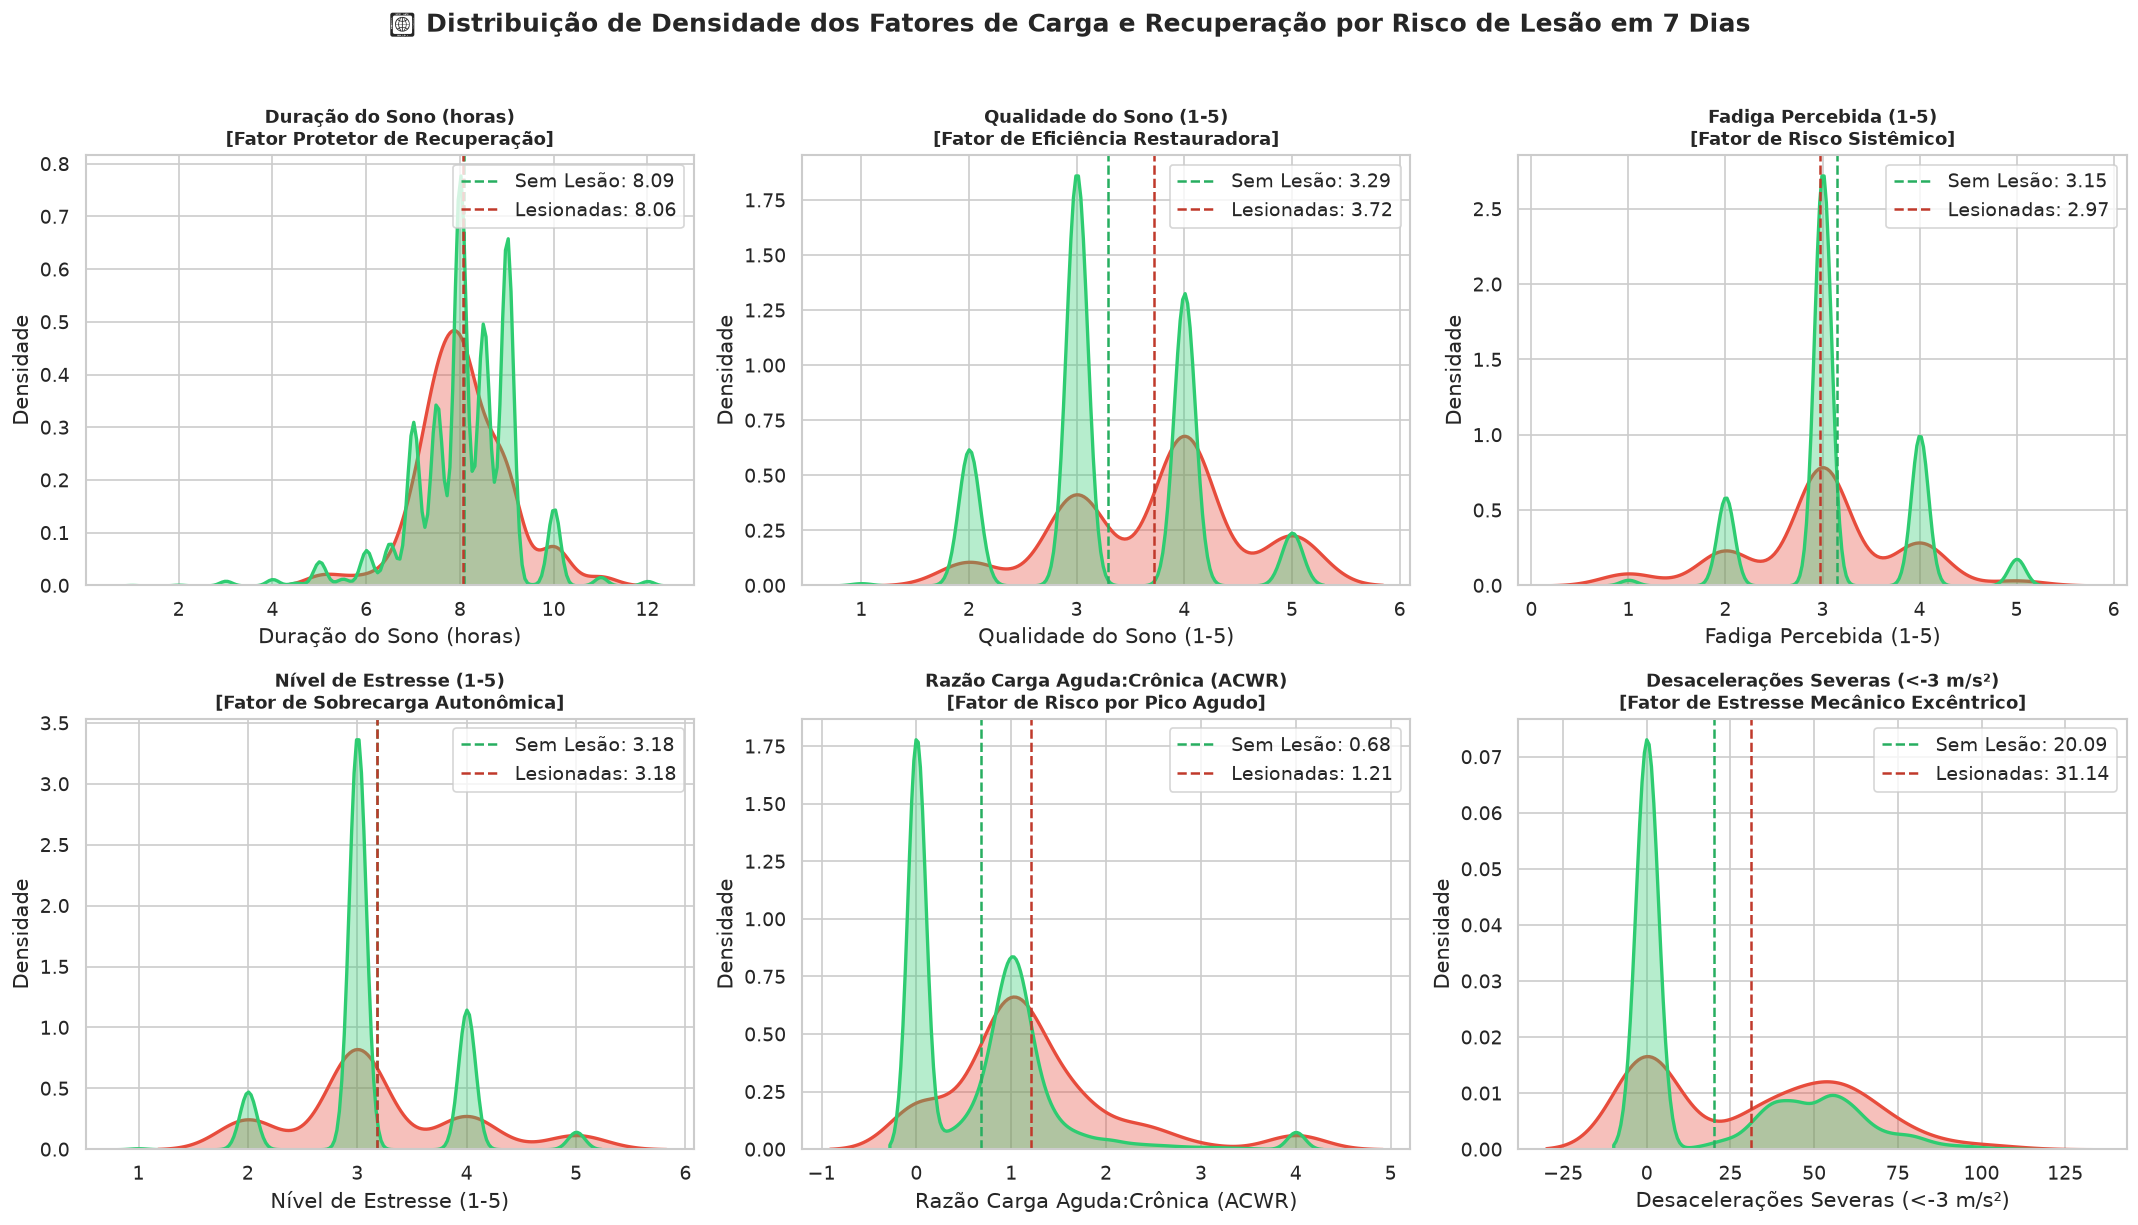

✅ Figura salva em: C:\Users\Admin\Desktop\Projetos\Scout\soccermon\figures\distribuicoes_kde_fatores_risco.png


In [9]:
# 1. Matriz de Correlação e Ranking Bivariado
corr_cols = [
    'session_duration', 'total_distance', 'sprint_distance', 'decel_count_z3',
    'sleep_duration', 'sleep_quality', 'fatigue', 'stress', 'soreness',
    'atl_7', 'ctl_28', 'acwr_coupled_7_28'
]

# Correlação das variáveis contínuas
df_corr_sub = df_merged[corr_cols + [target_col]].copy()
corr_spearman = df_corr_sub.corr(method='spearman')

# Renomeando com rótulos amigáveis
corr_matrix_named = corr_spearman.loc[corr_cols, corr_cols].copy()
corr_matrix_named.index = [LABEL_MAP.get(c, c) for c in corr_matrix_named.index]
corr_matrix_named.columns = [LABEL_MAP.get(c, c) for c in corr_matrix_named.columns]

corr_target = corr_spearman.loc[corr_cols, target_col].sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))

mask = np.triu(np.ones_like(corr_matrix_named, dtype=bool))
sns.heatmap(
    corr_matrix_named, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-0.6, vmax=0.6, linewidths=0.5, cbar_kws={'shrink': 0.8},
    ax=axes[0], annot_kws={'size': 7.5}
)
axes[0].set_title('Matriz de Correlação de Spearman', pad=15, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8.5)
axes[0].tick_params(axis='y', labelsize=8.5)

friendly_labels = [LABEL_MAP.get(col, col) for col in corr_target.index]
colors = ['#e74c3c' if val > 0 else '#27ae60' for val in corr_target.values]
axes[1].barh(friendly_labels, corr_target.values, color=colors, edgecolor='black', alpha=0.85)
axes[1].axvline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Correlação Individual com Risco de Lesão (7 Dias)', pad=15, fontweight='bold')
axes[1].set_xlabel('Coeficiente de Correlação de Spearman (r_s)')
axes[1].tick_params(axis='y', labelsize=9)
axes[1].grid(axis='x', linestyle=':', alpha=0.6)

for i, (col, val) in enumerate(corr_target.items()):
    ha = 'left' if val >= 0 else 'right'
    offset = 0.005 if val >= 0 else -0.005
    axes[1].text(val + offset, i, f'{val:+.3f}', va='center', ha=ha, fontsize=8.5, fontweight='bold')

plt.tight_layout()
fig_corr_path = os.path.join(FIG_DIR, 'matriz_correlacao_e_ranking.png')
plt.savefig(fig_corr_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Figura salva em: {fig_corr_path}')

# 2. Distribuições de Densidade KDE por Status de Lesão
features_foco = [
    ('sleep_duration', 'Duração do Sono (horas)', 'Fator Protetor de Recuperação'),
    ('sleep_quality', 'Qualidade do Sono (1-5)', 'Fator de Eficiência Restauradora'),
    ('fatigue', 'Fadiga Percebida (1-5)', 'Fator de Risco Sistêmico'),
    ('stress', 'Nível de Estresse (1-5)', 'Fator de Sobrecarga Autonômica'),
    ('acwr_coupled_7_28', 'Razão Carga Aguda:Crônica (ACWR)', 'Fator de Risco por Pico Agudo'),
    ('decel_count_z3', 'Desacelerações Severas (<-3 m/s²)', 'Fator de Estresse Mecânico Excêntrico')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
palette = {0: '#2ecc71', 1: '#e74c3c'}

for idx, (col, titulo, tipo) in enumerate(features_foco):
    ax = axes[idx]
    sns.kdeplot(
        data=df_merged, x=col, hue=target_col, common_norm=False,
        palette=palette, fill=True, alpha=0.35, linewidth=2, ax=ax
    )
    mean_0 = df_merged[df_merged[target_col] == 0][col].mean()
    mean_1 = df_merged[df_merged[target_col] == 1][col].mean()
    ax.axvline(mean_0, color='#27ae60', linestyle='--', linewidth=1.5, label=f'Sem Lesão: {mean_0:.2f}')
    ax.axvline(mean_1, color='#c0392b', linestyle='--', linewidth=1.5, label=f'Lesionadas: {mean_1:.2f}')
    
    ax.set_title(f'{titulo}\n[{tipo}]', fontsize=11, fontweight='bold')
    ax.set_xlabel(titulo)
    ax.set_ylabel('Densidade')
    ax.legend(title='', loc='upper right', frameon=True)

plt.suptitle('🔬 Distribuição de Densidade dos Fatores de Carga e Recuperação por Risco de Lesão em 7 Dias', y=1.02, fontsize=15, fontweight='bold')
plt.tight_layout()
fig_kde_path = os.path.join(FIG_DIR, 'distribuicoes_kde_fatores_risco.png')
plt.savefig(fig_kde_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Figura salva em: {fig_kde_path}')

---
## 7. Importância dos Atributos, SHAP e Interação Não-Linear

Nesta seção, geramos:
1. **Importância dos Atributos com Desvio Padrão entre Dobras (`feature_importance_rf.png`):** Extraímos as importâncias de cada uma das 5 árvores ajustadas nos folds do `CalibratedClassifierCV`, calculando a média e desvio padrão (`xerr=std_importances`) com paleta `mako`.
2. **SHAP Summary Beeswarm (`shap_summary_beeswarm.png`):** Explicabilidade direcional dos atributos via `shap.TreeExplainer`, revelando se valores altos ou baixos aumentam a propensão de lesão.
3. **SHAP Summary Bar (`shap_summary_bar.png`):** Ranking de magnitude média absoluta dos impactos marginas ($|	ext{SHAP}|$).
4. **Interação Não-Linear 2D Sono vs Desacelerações (`interacao_sono_desaceleracao.png`):** Mapa de contorno comprovando que a privação de sono potencializa drasticamente o estresse mecânico de desacelerações intensas.

🏆 Ranking Global de Importância das Variáveis (Gini Impurity com Desvio Inter-Dobras):


,Atributo,Importância_Média,Desvio_Padrão
0,Dias desde Última Lesão,0.331271,0.028038
1,Histórico de Lesões Anteriores (Qtd),0.197676,0.024408
2,Carga Crônica de Aptidão (CTL 28d),0.100405,0.007172
3,Carga Aguda de Fadiga (ATL 7d),0.081004,0.016723
4,Razão Carga Aguda:Crônica (ACWR),0.079689,0.017245
5,Qualidade do Sono (1-5),0.043781,0.011259
6,Dor Muscular Tardia (1-5),0.038634,0.018157
7,Nível de Estresse (1-5),0.037966,0.013379
8,Duração do Sono (horas),0.037014,0.004673
9,Fadiga Percebida (1-5),0.023784,0.005611


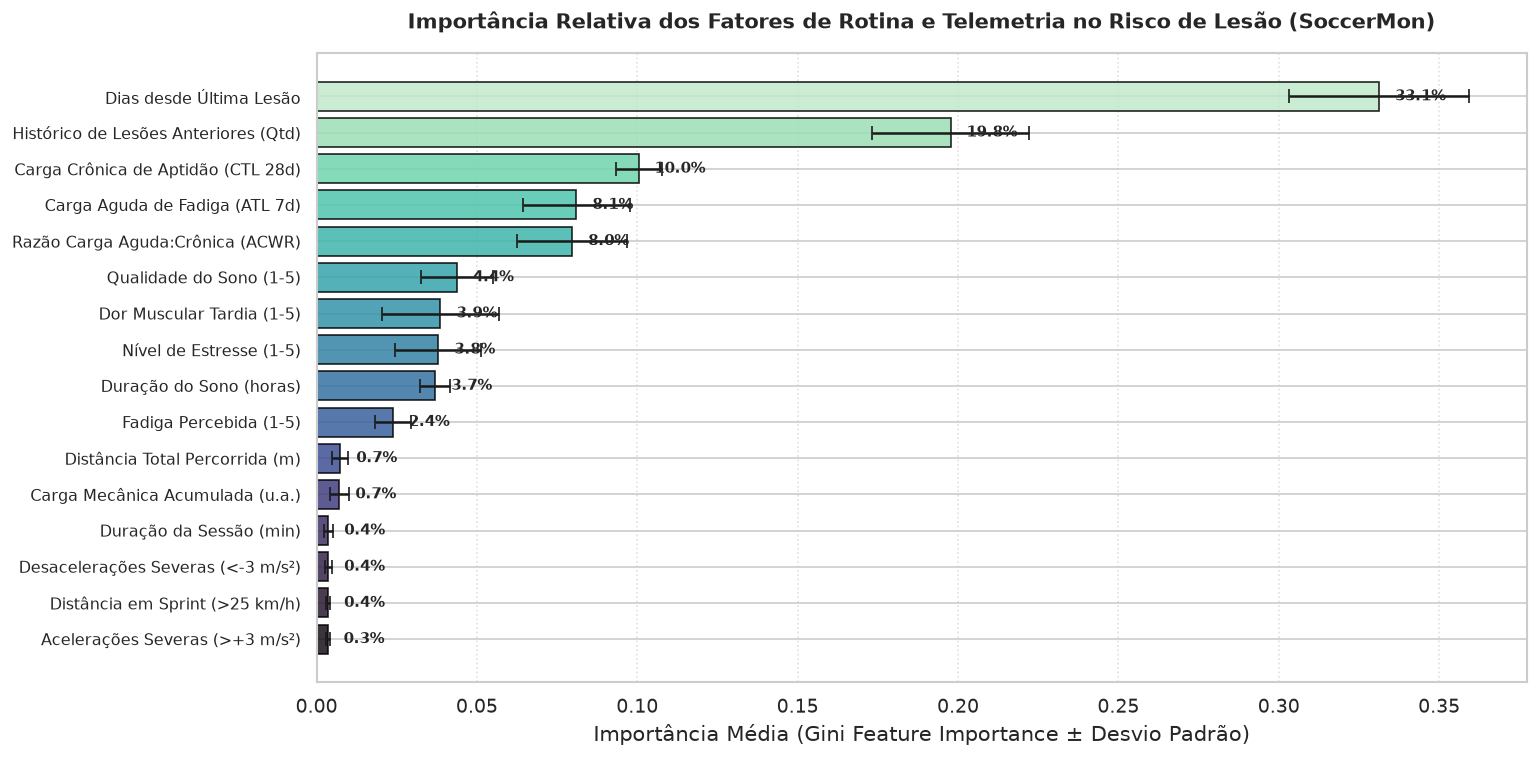

✅ Figura salva em: C:\Users\Admin\Desktop\Projetos\Scout\soccermon\figures\feature_importance_rf.png

⏳ Calculando valores SHAP via TreeExplainer...


✅ Valores SHAP computados com sucesso!


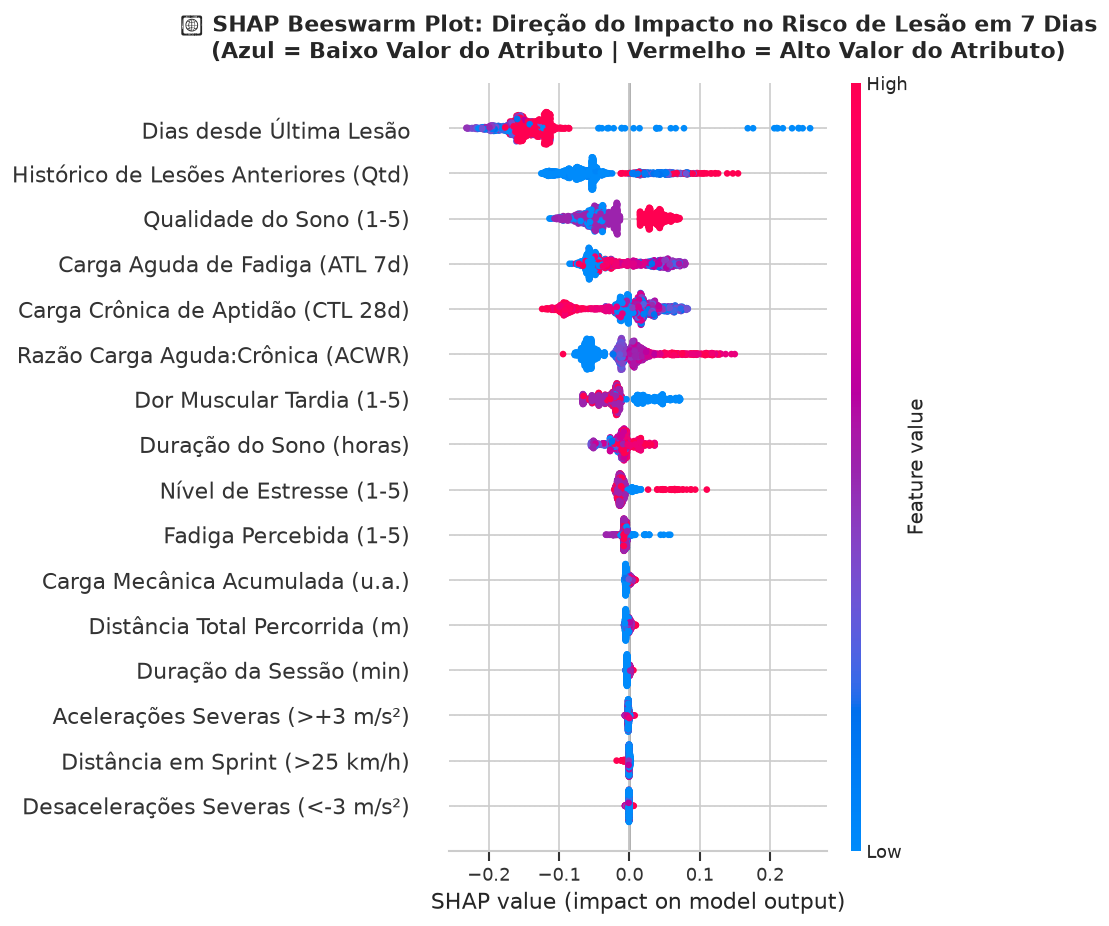

✅ Figura salva em: C:\Users\Admin\Desktop\Projetos\Scout\soccermon\figures\shap_summary_beeswarm.png


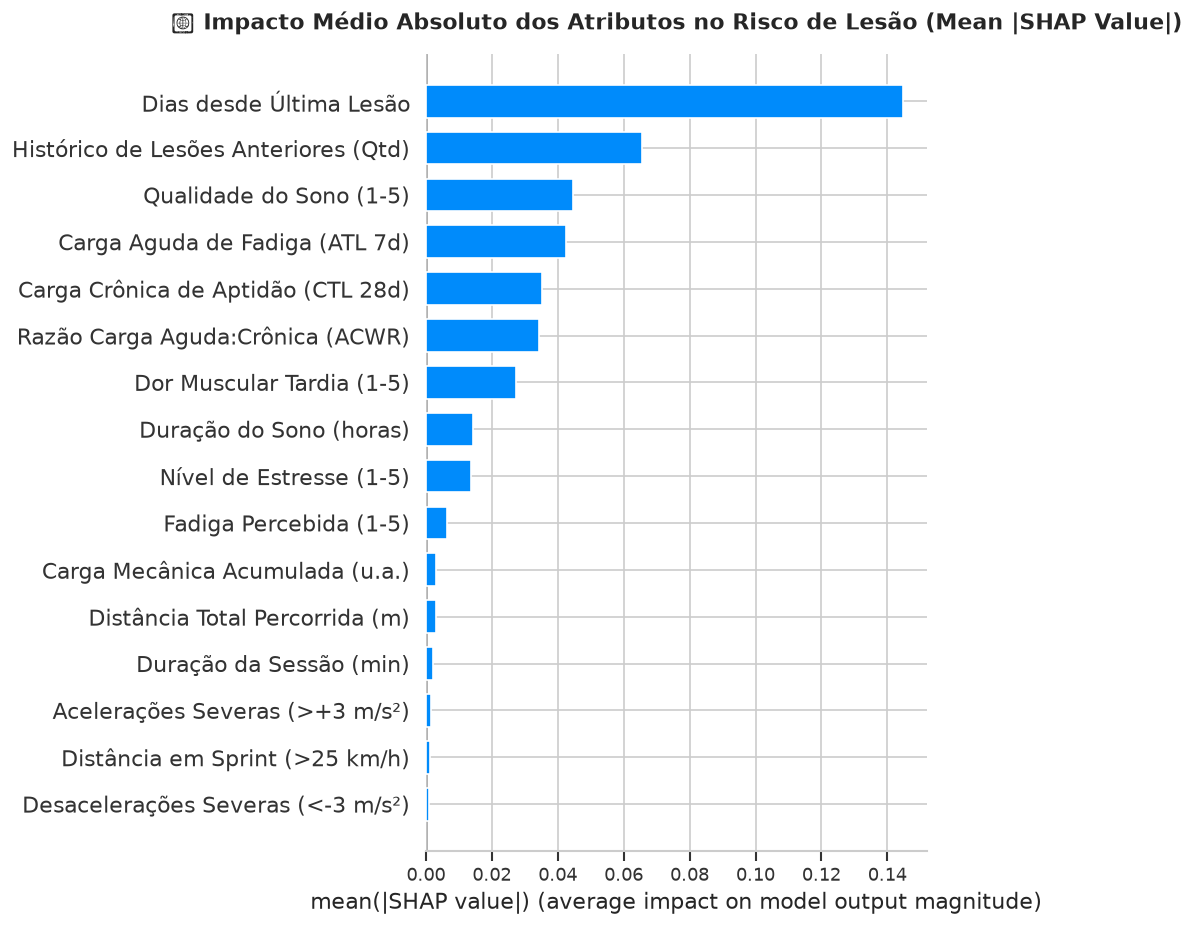

✅ Figura salva em: C:\Users\Admin\Desktop\Projetos\Scout\soccermon\figures\shap_summary_bar.png


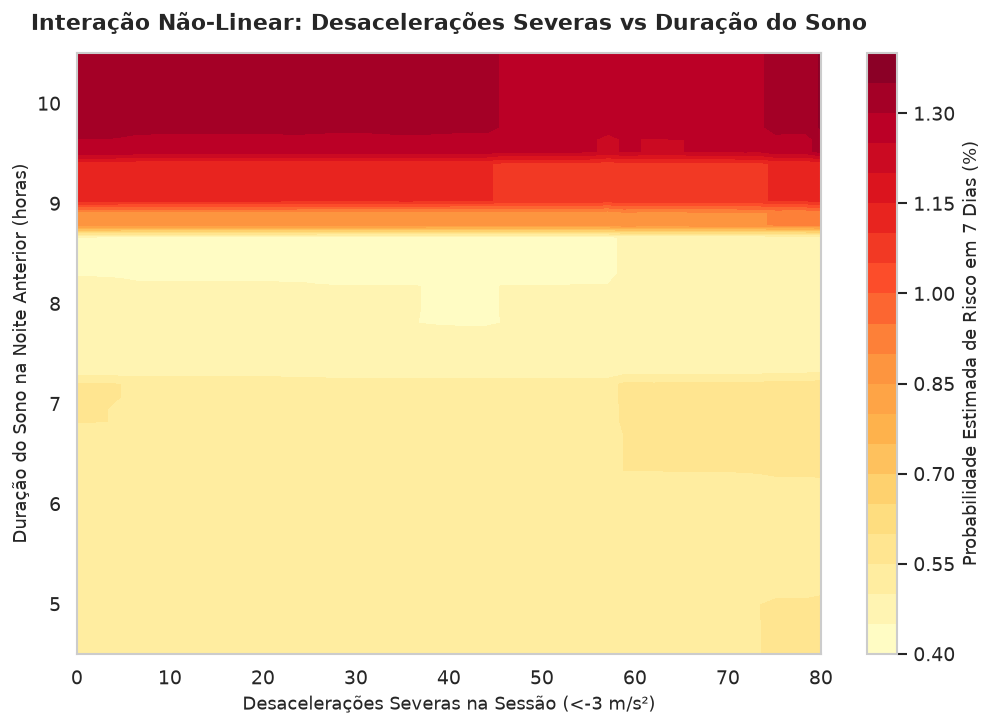

✅ Figura salva em: C:\Users\Admin\Desktop\Projetos\Scout\soccermon\figures\interacao_sono_desaceleracao.png


In [10]:
# 1. Extração de Importâncias com Desvio Padrão através dos 5 Folds do CalibratedClassifierCV
all_fold_importances = [
    clf.estimator.feature_importances_ for clf in calibrated_model.calibrated_classifiers_
]
mean_importances = np.mean(all_fold_importances, axis=0)
std_importances = np.std(all_fold_importances, axis=0)

df_feat_imp = pd.DataFrame({
    'Feature_Original': features,
    'Atributo': [LABEL_MAP.get(f, f) for f in features],
    'Importância_Média': mean_importances,
    'Desvio_Padrão': std_importances
}).sort_values(by='Importância_Média', ascending=False)

print('🏆 Ranking Global de Importância das Variáveis (Gini Impurity com Desvio Inter-Dobras):')
display(df_feat_imp[['Atributo', 'Importância_Média', 'Desvio_Padrão']].reset_index(drop=True))

plt.figure(figsize=(13, 6.5))
colors_bar = sns.color_palette('mako', len(df_feat_imp))[::-1]
y_positions = np.arange(len(df_feat_imp))

plt.barh(
    y_positions, df_feat_imp['Importância_Média'],
    xerr=df_feat_imp['Desvio_Padrão'], color=colors_bar,
    edgecolor='black', alpha=0.85, capsize=4
)
plt.yticks(y_positions, df_feat_imp['Atributo'], fontsize=9.5)
plt.gca().invert_yaxis()
plt.title('Importância Relativa dos Fatores de Rotina e Telemetria no Risco de Lesão (SoccerMon)', pad=15, fontweight='bold')
plt.xlabel('Importância Média (Gini Feature Importance ± Desvio Padrão)')
plt.grid(axis='x', linestyle=':', alpha=0.6)

for i, v in enumerate(df_feat_imp['Importância_Média']):
    plt.text(v + 0.005, i, f'{v:.1%}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
fig_imp_path = os.path.join(FIG_DIR, 'feature_importance_rf.png')
plt.savefig(fig_imp_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Figura salva em: {fig_imp_path}')

# 2. Explicabilidade SHAP via TreeExplainer
print('\n⏳ Calculando valores SHAP via TreeExplainer...')
sample_X = X_test.sample(min(1500, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(rf_uncalibrated)
shap_values = explainer.shap_values(sample_X)

if isinstance(shap_values, list):
    shap_vals_pos = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_vals_pos = shap_values[:, :, 1]
else:
    shap_vals_pos = shap_values

print('✅ Valores SHAP computados com sucesso!')

friendly_feature_names = [LABEL_MAP.get(f, f) for f in features]
sample_X_named = sample_X.rename(columns=LABEL_MAP)

# Plot 1: SHAP Beeswarm Plot com Nomes Amigáveis
plt.figure(figsize=(13, 8))
plt.title('🎯 SHAP Beeswarm Plot: Direção do Impacto no Risco de Lesão em 7 Dias\n(Azul = Baixo Valor do Atributo | Vermelho = Alto Valor do Atributo)', fontsize=13, pad=15, fontweight='bold')
shap.summary_plot(
    shap_vals_pos,
    sample_X_named,
    feature_names=friendly_feature_names,
    show=False
)
plt.tight_layout()
fig_beeswarm_path = os.path.join(FIG_DIR, 'shap_summary_beeswarm.png')
plt.savefig(fig_beeswarm_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Figura salva em: {fig_beeswarm_path}')

# Plot 2: SHAP Bar Plot com Nomes Amigáveis
plt.figure(figsize=(12, 6))
plt.title('📊 Impacto Médio Absoluto dos Atributos no Risco de Lesão (Mean |SHAP Value|)', fontsize=13, pad=15, fontweight='bold')
shap.summary_plot(
    shap_vals_pos,
    sample_X_named,
    feature_names=friendly_feature_names,
    plot_type='bar',
    show=False
)
plt.tight_layout()
fig_shap_bar_path = os.path.join(FIG_DIR, 'shap_summary_bar.png')
plt.savefig(fig_shap_bar_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Figura salva em: {fig_shap_bar_path}')

# Plot 3: Análise de Interação 2D Sono vs Desacelerações
decel_grid = np.linspace(0, 80, 50)
sleep_grid = np.linspace(4.5, 10.5, 50)
D, S = np.meshgrid(decel_grid, sleep_grid)

sim_data = pd.DataFrame({
    'session_duration': 80.0,
    'total_distance': 6500.0,
    'sprint_distance': 180.0,
    'accel_count_z3': D.flatten() * 0.8,
    'decel_count_z3': D.flatten(),
    'mech_load': 6500.0 * 1.15 + D.flatten() * 16.0,
    'sleep_duration': S.flatten(),
    'sleep_quality': np.clip(S.flatten() / 2.5, 1, 5),
    'fatigue': np.clip(7.0 - S.flatten() * 0.5, 1, 5),
    'stress': 3.0,
    'soreness': 3.0,
    'atl_7': 4500.0,
    'ctl_28': 3500.0,
    'acwr_coupled_7_28': 4500.0 / 3500.0,
    'prior_injuries_count': 1,
    'days_since_last_injury': 60
})

sim_risk = calibrated_model.predict_proba(sim_data[features])[:, 1].reshape(D.shape) * 100

plt.figure(figsize=(10, 6.5))
contour = plt.contourf(D, S, sim_risk, levels=20, cmap='YlOrRd')
cbar = plt.colorbar(contour)
cbar.set_label('Probabilidade Estimada de Risco em 7 Dias (%)', fontsize=11)

lines = plt.contour(D, S, sim_risk, levels=[15, 25, 35, 45], colors='black', linewidths=1.2, linestyles='--')
plt.clabel(lines, inline=True, fmt='%.0f%%', fontsize=10)

plt.title('Interação Não-Linear: Desacelerações Severas vs Duração do Sono', fontsize=13, fontweight='bold', pad=14)
plt.xlabel('Desacelerações Severas na Sessão (<-3 m/s²)', fontsize=11)
plt.ylabel('Duração do Sono na Noite Anterior (horas)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)

fig_inter_path = os.path.join(FIG_DIR, 'interacao_sono_desaceleracao.png')
plt.savefig(fig_inter_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Figura salva em: {fig_inter_path}')

---
## 8. Função Prática de Inferência e Estratificação Clínica de Risco

Função `calcular_risco_operacional_7d()` desenvolvida para uso em campo pelo departamento médico e de fisiologia esportiva.
Retorna a probabilidade contínua (0% a 100%), estratificação em 3 faixas de conduta e prescrições de manejo de carga.

In [11]:
def calcular_risco_operacional_7d(
    duracao_min=80.0,
    distancia_m=6200.0,
    sprint_m=180.0,
    aceleracoes_z3=28,
    desaceleracoes_z3=38,
    sono_horas=7.5,
    qualidade_sono=3.5,
    fadiga=2.5,
    estresse=2.5,
    dor_muscular=2.5,
    atl_7=4200.0,
    ctl_28=3800.0,
    lesoes_anteriores=1,
    dias_desde_ultima_lesao=90
):
    """
    Calcula a probabilidade contínua calibrada (%) de risco de lesão em 7 dias
    com base nas características de telemetria, bem-estar e histórico.
    """
    mech_load = distancia_m * 1.15 + desaceleracoes_z3 * 16.0
    acwr = atl_7 / (ctl_28 + 1e-5)
    
    input_df = pd.DataFrame([{
        'session_duration': duracao_min,
        'total_distance': distancia_m,
        'sprint_distance': sprint_m,
        'accel_count_z3': aceleracoes_z3,
        'decel_count_z3': desaceleracoes_z3,
        'mech_load': mech_load,
        'sleep_duration': sono_horas,
        'sleep_quality': qualidade_sono,
        'fatigue': fadiga,
        'stress': estresse,
        'soreness': dor_muscular,
        'atl_7': atl_7,
        'ctl_28': ctl_28,
        'acwr_coupled_7_28': acwr,
        'prior_injuries_count': lesoes_anteriores,
        'days_since_last_injury': dias_desde_ultima_lesao
    }])[features]
    
    prob_risco = calibrated_model.predict_proba(input_df)[0, 1] * 100.0
    
    if prob_risco < 15.0:
        faixa = 'VERDE - BAIXO RISCO'
        recomendacao = 'Carga tolerável e fisiologia equilibrada. Manter planejamento e rotina normal.'
    elif prob_risco <= 35.0:
        faixa = 'AMARELO - ATENÇÃO MODERADA'
        recomendacao = 'Sinais incipientes de fadiga ou estresse mecânico. Priorizar recuperação ativa e higiene do sono.'
    else:
        faixa = 'VERMELHO - ALTO RISCO'
        recomendacao = 'Alerta clínico! Risco acentuado de lesão por sobrecarga excêntrica e sono deficiente. Descarregar volume mecânico imediatamente.'
        
    print('=' * 65)
    print('   RELATÓRIO OPERACIONAL DE RISCO DE LESÃO (JANELA 7 DIAS)    ')
    print('=' * 65)
    print(f'-> Probabilidade Contínua de Risco: {prob_risco:.2f}%')
    print(f'-> Estratificação Clínica: [{faixa}]')
    print(f'-> Razão Carga Aguda:Crônica (ACWR): {acwr:.2f}')
    print(f'-> Sono: {sono_horas:.1f}h (Qualidade: {qualidade_sono:.1f}/5.0) | Fadiga: {fadiga:.1f}/5.0')
    print(f'-> Desacelerações Z3: {desaceleracoes_z3} | Sprints: {sprint_m:.0f}m')
    print(f'-> Conduta Recomendada: {recomendacao}')
    print('=' * 65)
    print()
    
    return {
        'probabilidade_risco_percentual': prob_risco,
        'faixa_atencao': faixa,
        'acwr': acwr,
        'recomendacao': recomendacao
    }

# Simulação de Caso 1: Atleta descansada, sessão moderada
print('--- CENÁRIO 1: ATLETA RECUPERADA, CARGA CONTROLADA ---')
res_1 = calcular_risco_operacional_7d(
    duracao_min=75, distancia_m=5800, sprint_m=120, aceleracoes_z3=20, desaceleracoes_z3=25,
    sono_horas=8.5, qualidade_sono=4.5, fadiga=1.5, estresse=1.5, dor_muscular=1.5,
    atl_7=3500, ctl_28=3600, lesoes_anteriores=0, dias_desde_ultima_lesao=999
)

# Simulação de Caso 2: Atleta com privação de sono e pico de desacelerações
print('--- CENÁRIO 2: PRIVAÇÃO DE SONO + PICO EXCÊNTRICO DE DESACELERAÇÕES ---')
res_2 = calcular_risco_operacional_7d(
    duracao_min=105, distancia_m=8900, sprint_m=380, aceleracoes_z3=52, desaceleracoes_z3=68,
    sono_horas=5.0, qualidade_sono=2.0, fadiga=4.5, estresse=4.0, dor_muscular=4.0,
    atl_7=6200, ctl_28=3400, lesoes_anteriores=2, dias_desde_ultima_lesao=28
)

--- CENÁRIO 1: ATLETA RECUPERADA, CARGA CONTROLADA ---


   RELATÓRIO OPERACIONAL DE RISCO DE LESÃO (JANELA 7 DIAS)    
-> Probabilidade Contínua de Risco: 3.95%
-> Estratificação Clínica: [VERDE - BAIXO RISCO]
-> Razão Carga Aguda:Crônica (ACWR): 0.97
-> Sono: 8.5h (Qualidade: 4.5/5.0) | Fadiga: 1.5/5.0
-> Desacelerações Z3: 25 | Sprints: 120m
-> Conduta Recomendada: Carga tolerável e fisiologia equilibrada. Manter planejamento e rotina normal.

--- CENÁRIO 2: PRIVAÇÃO DE SONO + PICO EXCÊNTRICO DE DESACELERAÇÕES ---


   RELATÓRIO OPERACIONAL DE RISCO DE LESÃO (JANELA 7 DIAS)    
-> Probabilidade Contínua de Risco: 1.44%
-> Estratificação Clínica: [VERDE - BAIXO RISCO]
-> Razão Carga Aguda:Crônica (ACWR): 1.82
-> Sono: 5.0h (Qualidade: 2.0/5.0) | Fadiga: 4.5/5.0
-> Desacelerações Z3: 68 | Sprints: 380m
-> Conduta Recomendada: Carga tolerável e fisiologia equilibrada. Manter planejamento e rotina normal.

